# Ingénierie de l’apprentissage automatique

CSI 4506 - automne 2026

Marcel Turcotte  
Version: août 9, 2026 12h17

# Préambule

## Message du jour

![](https://www.uottawa.ca/about-us/sites/g/files/bhrskd336/files/styles/max_width_xl_5120px/public/2025-09/vitalii-pavlyshynets-kcRFW-Hje8Y-unsplash.jpg)

[L’Université d’Ottawa met au point un outil alimenté par l’IA qui
génère des menus personnalisés pour les personnes atteintes du syndrome
du côlon
irritable](https://www.uottawa.ca/notre-universite/toutes-nouvelles/luniversite-dottawa-met-au-point-outil-alimente-lia-qui-genere-menus-personnalises),
2025-09-23.

La Fondation de la famille Weston a octroyé une subvention de 10
millions de dollars à un projet de recherche collaboratif entre
l’Université d’Ottawa et l’Université de l’Alberta. Cette initiative
vise à mener des recherches novatrices sur syndrome du côlon irritable
(SCI).

Au Canada, plus de 300 000 personnes souffrent de SCI chroniques, qui
incluent des affections telles que la maladie de Crohn et la colite
ulcéreuse. Le projet s’appuiera sur les données de RapidAIM, une
plateforme développée à l’Université d’Ottawa conçue pour évaluer
rapidement les effets de divers composés sur les microbiomes
individuels.

Un objectif clé de cette recherche est de poser les bases pour former un
modèle d’intelligence artificielle (IA). Ce modèle sera capable de
générer des recommandations alimentaires personnalisées, adaptées aux
profils microbiens uniques des individus atteints du SCI.

## Objectifs d’apprentissage

- **Expliquer** l’extraction de attributs, **comparer** les méthodes de
  codage, et **justifier** les choix en fonction de la nature des
  données.
- **Appliquer** la normalisation/standardisation pour l’échelle des
  attributs et **gérer** les valeurs manquantes par imputation.
- **Définir** le déséquilibre des classes, **explorer** des solutions
  comme le rééchantillonnage et SMOTE, et garantir une application
  appropriée.
- **Appliquer** les concepts à des ensembles de données du monde réel,
  analyser les résultats, et comprendre le pipeline d’apprentissage
  automatique.
- **Reconnaître** l’impact de la taille de l’ensemble de données,
  **discuter** de l’augmentation des données, et **explorer**
  l’efficacité des données dans l’apprentissage automatique.

# L’ingénierie de l’apprentissage automatique

## Ingénierie de l’apprentissage automatique

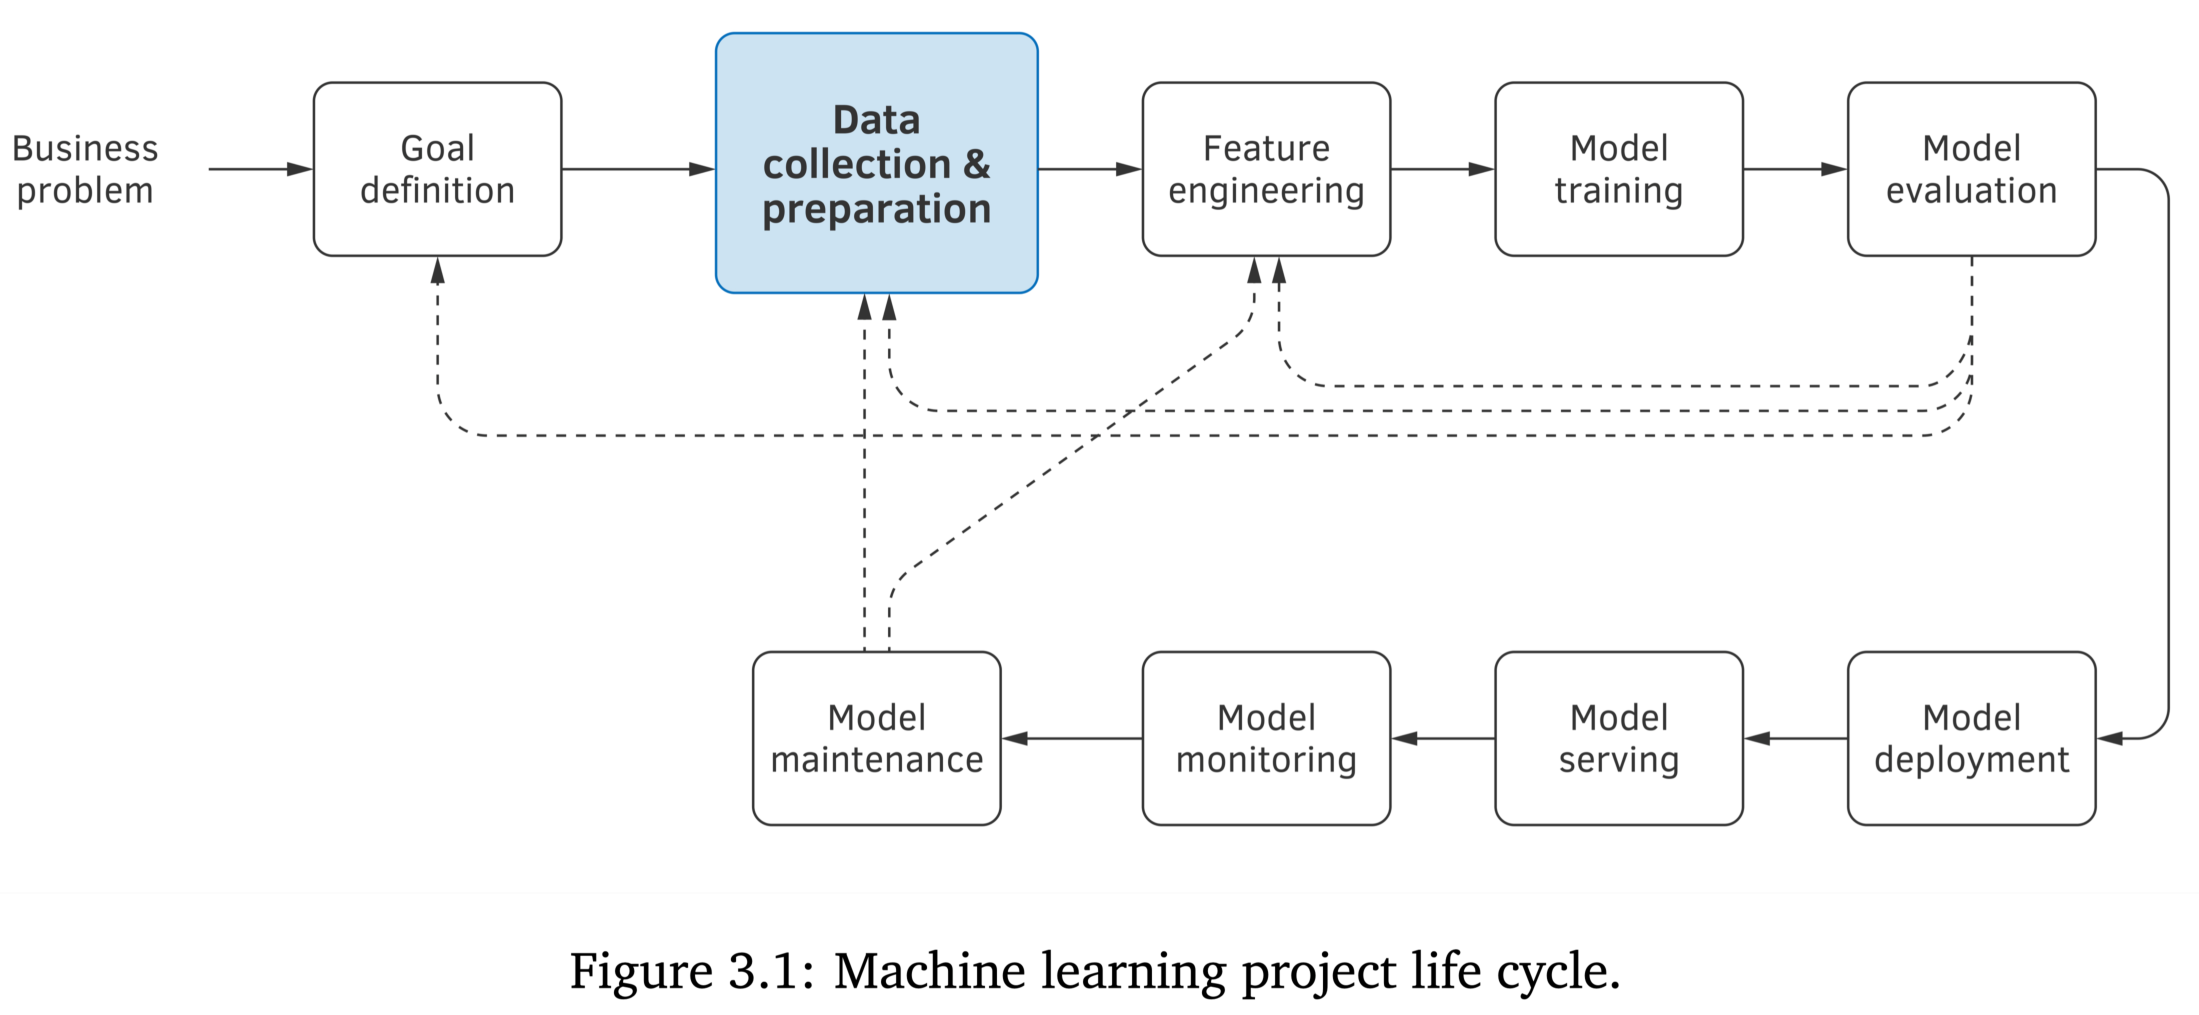

**Attribution :** Burkov (2020), Figure 3.1

Les cours [SDS 3786: Laboratoire de Science des
Données](https://catalogue.uottawa.ca/search/?P=SDS%203386) et [CSI
4542: Fondements de la Science des
Données](https://catalogue.uottawa.ca/search/?P=CSI%204142) offrent une
couverture complète de l’ingénierie de l’apprentissage automatique. Pour
ceux qui ne sont pas inscrits à ces cours, nous fournissons un aperçu
des concepts essentiels.

Comme illustré, le cycle de vie d’un projet d’apprentissage automatique
implique généralement plusieurs itérations. Chaque cycle améliore la
compréhension du problème et révèle des limitations. Une qualité de
données insuffisante mène souvent à l’échec du projet.

### Caractéristiques des données de haute qualité

- **Volume** : Le jeu de données est-il suffisamment grand pour soutenir
  la généralisation ?
- **Pertinence** : Les attributs modélisent-ils précisément le problème
  ?
- **Représentation** : Les données reflètent-elles les conditions
  attendues en production ?
  - Ces attributs sont-ils obtenables à partir d’entrées réelles ?
  - Le jeu de données couvre-t-il et représente-t-il adéquatement les
    exemples de attributs ?
- **Biais** : Les données sont-elles exemptes de biais ?
- **Cohérence des Étiquettes** : Les étiquettes sont-elles cohérentes
  dans l’ensemble du jeu de données ?

### Cycle de projet d’apprentissage automatique

La collecte de données et l’extraction des attributs sont les deux
premières étapes d’un projet d’apprentissage automatique.

1.  Recueillir des données **adéquates**.
2.  Extraire des **attributs** des données brutes :
    - Ce processus est **laborieux**.
    - Il nécessite de la **créativité**.
    - La **connaissance du domaine** est très bénéfique.

# Encodage

## Pourquoi?

Après avoir complété le devoir 1, vous avez généré un fichier `.csv`
contenant des données nettoyées.

Pourquoi des étapes supplémentaires seraient nécessaires?

## Données - Adult

In [2]:
import numpy as np
np.random.seed(42)

from sklearn.datasets import fetch_openml

adult = fetch_openml(name='adult', version=2)

print(adult.DESCR)

Le jeu de données ‘Adult’ contient plusieurs attributs caractérisés par
des valeurs catégorielles. Ce jeu de données servira de base pour une
brève discussion sur l’encodage de ces valeurs catégorielles.

## Adult - Workclass

In [3]:
adult.data['workclass'].unique()

['Private', 'Local-gov', NaN, 'Self-emp-not-inc', 'Federal-gov', 'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked']
Categories (8, str): ['Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay']

## Adult - Education

In [4]:
adult.data['education'].unique()

['11th', 'HS-grad', 'Assoc-acdm', 'Some-college', '10th', ..., 'Assoc-voc', '9th', '12th', '1st-4th', 'Preschool']
Length: 16
Categories (16, str): ['10th', '11th', '12th', '1st-4th', ..., 'Masters', 'Preschool', 'Prof-school', 'Some-college']

## Adult - Marital Status

In [5]:
adult.data['marital-status'].unique()

['Never-married', 'Married-civ-spouse', 'Widowed', 'Divorced', 'Separated', 'Married-spouse-absent', 'Married-AF-spouse']
Categories (7, str): ['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed']

## Données catégorielles

**Points clés sur la représentation des données**

- **Représentation numérique**: Certains algorithmes d’apprentissage
  nécessitent que les données soient sous forme numérique.

## Méthodes d’encodage

Considérons l’attribut `workclass`, qui a 8 valeurs distinctes telles
que ‘Federal-gov’, ‘Local-gov’, etc.

- **Quelle** méthode d’encodage est préférable et **pourquoi?**

1.  `w` = 1, 2, 3, 4, 5, 6, 7, ou 8
2.  `w` = \[0,0,0\], \[0,0,1\], \[0,1,0\], $\ldots$, ou \[1,1,1\]
3.  `w` = \[1,0,0,0,0,0,0,0\], \[0,1,0,0,0,0,0,0\], $\ldots$, ou
    \[0,0,0,0,0,0,0,1\]

## Encodage pour les données catégorielles

**Encodage One-Hot**: Cette méthode est à privilégier pour les données
catégorielles.

- **Augmente la dimensionnalité**: L’encodage One-Hot augmente la
  dimensionnalité des vecteurs de attributs.
- **Évite les biais**: Les autres méthodes d’encodage peuvent introduire
  des biais.
- **Exemple de biais**: En utilisant la première méthode, `w` = 1, 2, 3,
  etc., cela implique que ‘Federal-gov’ et ‘Local-gov’ sont similaires,
  tandis que ‘Federal-gov’ et ‘Without-pay’ ne le sont pas.
- **Similitude trompeuse**: La deuxième méthode, `w` = \[0,0,0\],
  \[0,0,1\], etc., pourrait induire en erreur l’algorithme en suggérant
  une similarité basée sur des schémas numériques.

## Définition

**Encodage One-Hot**: Une technique qui convertit les variables
catégorielles en une représentation vectorielle binaire, où chaque
catégorie est représentée par un vecteur avec un seul ‘1’ et tous les
autres éléments à ‘0’.

Il existe de nombreuses autres représentations vectorielles, parmi
lesquelles les “**embeddings**” se distinguent par leur efficacité
remarquable.

## OneHotEncoder

In [6]:
from numpy import array
from sklearn.preprocessing import OneHotEncoder

work = adult.data[['workclass']]

onehot_encoder = OneHotEncoder()

onehot_encoder.fit(work)
values_encoded = onehot_encoder.transform(work)

for i in range(5): print(values_encoded.toarray()[i])

[0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 1.]

**La cohérence est cruciale**: Assurez-vous d’utiliser le même encodage
pour : ensemble de validation, ensemble de test, et données en
production.

Une personne de mon groupe de recherche a rencontré un problème
difficile à déboguer. Elle a par erreur créé un nouvel encodeur pour
l’ensemble de test en utilisant
`onehot_encoder.fit(X_test['some_attribute'])`, ce qui a produit une
représentation vectorielle différente de celle utilisée lors de
l’entraînement. Par conséquent, les résultats sur l’ensemble test
étaient médiocres, tandis que les résultats sur l’ensemble
d’entraînement semblaient satisfaisants.

Bien que `Pandas` propose une méthode appelée `get_dummies()` pour
l’encodage One-Hot, il est important de noter les distinctions suivantes
:

- **Mémoire des catégories**: `OneHotEncoder` conserve les catégories
  sur lesquelles il a été entraîné, tandis que `get_dummies()` ne le
  fait pas.
- **Cohérence en production**: Il est essentiel d’utiliser le même
  schéma d’encodage en production que celui utilisé lors de
  l’entraînement pour garantir des résultats précis.
- **Différences de longueur de vecteur**: Si `get_dummies()` rencontre
  un nombre différent de catégories dans de nouvelles données, il
  produira des vecteurs de longueurs variables, ce qui peut entraîner
  des erreurs.
- **Gestion des valeurs manquantes**: Lors de la gestion des valeurs
  manquantes, `get_dummies()` génère une colonne supplémentaire pour les
  prendre en compte.

## Étude de cas

- **Ensemble de données** : [Heart
  Disease](https://archive.ics.uci.edu/dataset/45/heart+disease)
  - **Exemples** : 303, **Attributs** : 13, **Cible** : Présence/absence
    de maladie
- **Données catégorielles** :
  - **sexe** : 1 = homme, 0 = femme
  - **cp (type de douleur thoracique)** :
    - 1 : Angine typique
    - 2 : Angine atypique
    - 3 : Douleur non angineuse
    - 4 : Asymptomatique
  - **Autres** : ‘fbs’, ‘restecg’, ‘exang’, ‘slope’, ‘thal’

**Pour simplifier l’analyse** : Les exemples avec des valeurs manquantes
ont été supprimés, aucun ajustement d’hyperparamètres n’a été effectué,
les valeurs numériques ont été mises à l’échelle pour la convergence des
solveurs.

Voici quelques suggestions pour des recherches ultérieures :

- Évaluer l’impact de l’omission des valeurs manquantes sur l’ensemble
  de données.
- Implémenter l’ajustement des hyperparamètres pour déterminer si la
  régularisation $L_1$ ou $L_2$ améliore les performances du modèle.

## Étude de cas

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Chargement de l'ensemble de données 'Heart-Disease' depuis OpenML
data = fetch_openml(name='Heart-Disease', version=1, as_frame=True)
df = data.frame

# Remplacer '?' par NaN et convertir les colonnes en numérique
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Supprimer les lignes avec des valeurs manquantes
df.dropna(inplace=True)

# Définir les attributs et la cible
X = df.drop(columns=['target'])
y = df['target']

# Colonnes à encoder avec OneHotEncoder
colonnes_a_encoder = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# Identifier les colonnes numériques
colonnes_numeriques = X.columns.difference(colonnes_a_encoder)

# Diviser l'ensemble de données en ensembles d'entraînement et de test avant les transformations
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Appliquer OneHotEncoder et StandardScaler à l'aide de ColumnTransformer
column_transformer = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(), colonnes_a_encoder),
        ('scaler', StandardScaler(), colonnes_numeriques)
    ]
)

# Ajuster le transformateur sur les données d'entraînement et transformer les données d'entraînement et de test
X_train_processed = column_transformer.fit_transform(X_train)
X_test_processed = column_transformer.transform(X_test)

# Initialiser et entraîner le modèle de régression logistique
model = LogisticRegression(max_iter=1000)
model = model.fit(X_train_processed, y_train)

Dans le cadre de l’utilisation de `ColumnTransformer`, le second élément
des triplets, habituellement un estimateur, peut également être remplacé
par les options `drop` ou `passthrough`. L’option `drop` permet
d’exclure la colonne concernée du processus de transformation, tandis
que `passthrough` préserve la colonne dans son état initial, sans
apporter de modifications.

## Étude de cas - résultats

In [8]:
# Prédire et évaluer le modèle
y_pred = model.predict(X_test_processed)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.87      0.93      0.90        29
         1.0       0.93      0.88      0.90        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61


## Étude de cas - douleur thoracique (cp)

In [9]:
# Récupérer les noms des attributs après transformation à l'aide de get_feature_names_out()
feature_names = column_transformer.get_feature_names_out()

# Obtenir les coefficients et les associer aux noms des attributs
coefficients = model.coef_[0]

# Créer un DataFrame avec les noms des attributs et les coefficients
coef_df = pd.DataFrame({
    'Attribut': feature_names,
    'Coefficient': coefficients
})

# Afficher les coefficients associés à 'cp'
cp_features = coef_df[coef_df['Attribut'].str.contains('_cp')]
print("\nCoefficients associés à 'cp' :")
print(cp_features)


Coefficients associés à 'cp' :
         Attribut  Coefficient
2  onehot__cp_0.0    -1.013382
3  onehot__cp_1.0    -0.212284
4  onehot__cp_2.0     0.599934
5  onehot__cp_3.0     0.628824

## Étude de cas - coefficients

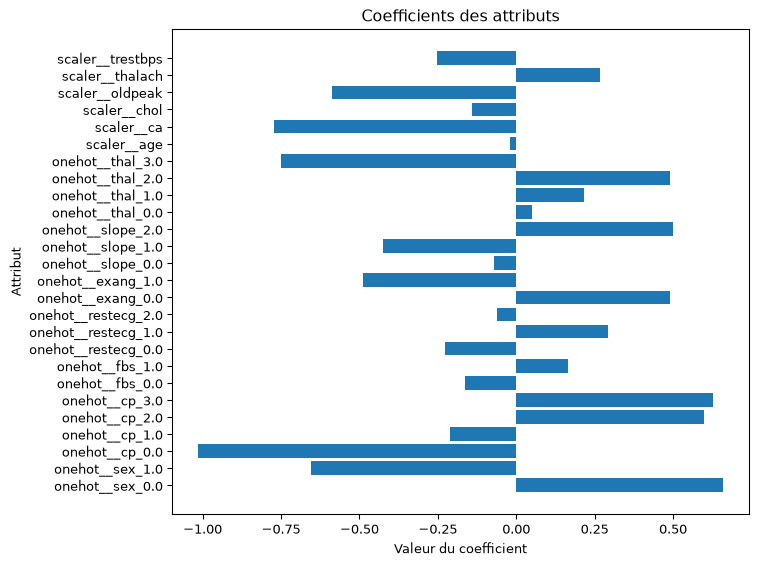

In [10]:
# Visualiser les coefficients

plt.figure(figsize=(8, 6))
plt.barh(coef_df['Attribut'], coef_df['Coefficient'])
plt.title('Coefficients des attributs')
plt.xlabel('Valeur du coefficient')
plt.ylabel('Attribut')
plt.tight_layout()
plt.show()

Les **coefficients positifs** dans un modèle de régression logistique
signifient que **des valeurs plus élevées de l’attribut correspondant
contribuent positivement** à la probabilité qu’un exemple **appartienne
à ‘target = 1.0’**. Les coefficients négatifs indiquent l’effet opposé.

## Étude de cas - coefficients (triés)

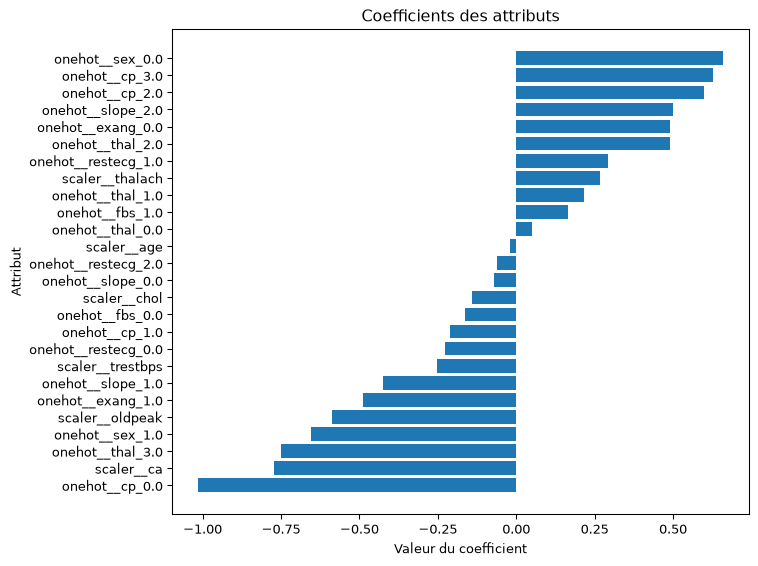

In [11]:
# Visualiser les coefficients

plt.figure(figsize=(8, 6))
coef_df.sort_values(by='Coefficient', inplace=True)
plt.barh(coef_df['Attribut'], coef_df['Coefficient'])
plt.title('Coefficients des attributs')
plt.xlabel('Valeur du coefficient')
plt.ylabel('Attribut')
plt.tight_layout()
plt.show()

## Définition

**L’encodage ordinal** est une technique qui attribue des valeurs
numériques aux attributs catégoriels en fonction de leur ordre ou de
leur classement intrinsèque.

## Encodage ordinal

Pour les attributs avec des valeurs comme **‘Mauvais’**, **‘Moyen’**, et
**‘Bon’**, un encodage ordinal aurait du sens.

. . .

Cependant !

In [12]:
from numpy import array
from sklearn.preprocessing import OrdinalEncoder

X =[['Mauvais'], ['Moyen'], ['Bon'], ['Moyen'], ['Moyen']]

encoder = OrdinalEncoder()

encoder.fit(X)
encoder.transform(X)

array([[1.],
       [2.],
       [0.],
       [2.],
       [2.]])

## OrdinalEncoder (révisé)

In [13]:
from numpy import array
from sklearn.preprocessing import OrdinalEncoder

X =[['Mauvais'], ['Moyen'], ['Bon'], ['Moyen'], ['Moyen']]

encoder = OrdinalEncoder(categories=[['Mauvais', 'Moyen', 'Bon']])

encoder.fit(X)

X_encoded = encoder.transform(X)

X_encoded

array([[0.],
       [1.],
       [2.],
       [1.],
       [1.]])

L’ordre souhaité des catégories doit être fourni explicitement à
l’encodeur ; sinon, il adopte l’ordre alphabétique par défaut.

Un encodeur ordinal est approprié lorsque les attributs catégoriels ont
un ordre ou un classement clair et intrinsèque, comme ‘Faible’, ‘Moyen’,
et ‘Élevé’, ou ‘Mauvais’, ‘Moyen’, et ‘Bon’. Cette méthode d’encodage
préserve les relations ordinales entre les catégories.

Lorsque les données sont intrinsèquement ordinales, cet encodage est
plus compact et peut être avantageux pour les modèles d’apprentissage
automatique. Cependant, si l’ordinalité des données est incertaine, il
est plus sûr d’utiliser un `OneHotEncoder`.

## Définition

**La discrétisation** consiste à regrouper des valeurs ordinales en
catégories discrètes.

Aussi appelée **binning**, **bucketing**, ou **quantification**.

## Ingénierie des attributs : Binning

**Exemple** : Catégoriser les âges en groupes tels que ‘nourrisson’,
‘enfant’, ‘adolescent’, ‘adulte’, et ‘senior’.

. . .

**Avantages** :

- Permet à l’algorithme d’apprendre efficacement avec moins d’exemples
  d’entraînement.

**Inconvénients** :

- Nécessite une expertise dans le domaine pour définir des catégories
  significatives.
- Peut manquer de généralisabilité ; par exemple, l’âge de départ pour
  ‘senior’ pourrait être 60, 65 ou 70[1].

Fournir des indices ou des catégories prédéfinies peut aider un
algorithme d’arbre de décision à générer des arbres plus compacts, car
cela réduit la nécessité pour le classificateur d’apprendre
indépendamment les limites de décision.

Cependant, introduire un tel biais fort peut nuire à la capacité de
l’algorithme à découvrir des limites de décision significatives par
lui-même.

La validation croisée est un moyen efficace pour déterminer la meilleure
méthode d’encodage, mais il est essentiel de retenir l’ensemble de test
jusqu’à la phase finale d’évaluation du projet pour éviter toute fuite
de données et garantir une évaluation impartiale.

## FunctionTransformer

[1] Votre professeur s’inquiète de votre choix de seuil

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import FunctionTransformer

bins = [0, 1, 13, 20, 60, np.inf]
labels = ['nourrisson', 'enfant', 'adolescent', 'adulte', 'senior']

transformer = FunctionTransformer(
    pd.cut, kw_args={'bins': bins, 'labels': labels, 'retbins': False}
)

X = np.array([0.5, 2, 15, 25, 97])
transformer.fit_transform(X)

['nourrisson', 'enfant', 'adolescent', 'adulte', 'senior']
Categories (5, str): ['nourrisson' < 'enfant' < 'adolescent' < 'adulte' < 'senior']

Voir aussi :
[KBinsDiscretizer](https://scikit-learn.org/dev/modules/generated/sklearn.preprocessing.KBinsDiscretizer.html#sklearn.preprocessing.KBinsDiscretizer)

# Mise à l’échelle

## Qu’est-ce que c’est ?

**Mettre à l’échelle les attributs** garantit que leurs valeurs se
situent dans des **plages comparables**.

## Pourquoi ?

Pourquoi la mise à l’échelle des données est-elle une bonne pratique ?

La mise à l’échelle des attributs garantit que leurs valeurs se situent
dans des intervalles comparables. De nombreuses études indiquent que
cette transformation améliore les performances des modèles.

Certains algorithmes, tels que les k-plus proches voisins, voient leur
efficacité diminuer en présence de disparités importantes dans l’échelle
des attributs. Considérons deux attributs : l’un exprimant une
proportion sous forme de nombre réel compris entre 0 et 1, et l’autre
mesurant un volume en millilitres. Dans ce cas, la distance calculée
entre deux exemples sera principalement influencée par les variations de
volume plutôt que par celles de la proportion. Les algorithmes basés sur
des arbres sont généralement insensibles à l’échelle des données, et par
conséquent, la mise à l’échelle n’est pas nécessaire.

De surcroît, les méthodes d’optimisation, telles que la descente de
gradient, atteignent la convergence plus rapidement lorsque les
attributs ont été mis à l’échelle.

La normalisation peut être significativement influencée par la présence
de valeurs aberrantes, ce qui souvent comprime les données dans une
plage plus étroite. Pour atténuer cet effet, une approche courante
consiste à limiter les données à un intervalle fixe, $[a, b]$. Dans
cette méthode, les valeurs inférieures à $a$ sont fixées à $a$, et les
valeurs dépassant $b$ sont fixées à $b$. En général, les seuils de
découpage sont choisis en fonction des valeurs percentiles, comme les 5e
et 95e percentiles, pour garantir une réduction équilibrée des valeurs
extrêmes.

## Scénario

Nous prétendons prédire le prix d’une maison en utilisant la
**régression par les k-plus proches voisins (KNN)** avec deux attributs
:

- $x_1$ : nombre de pièces (petite échelle)
- $x_2$ : superficie en pieds carrés (grande échelle)

## Données (trois maisons)

In [15]:
import numpy as np
import pandas as pd

# Trois exemples (pièces, sqft); prix seulement pour b et c (entraînement)
point_names = ["a", "b", "c"]
X = np.array([
    [4, 1500.0],  # a (requête)
    [8, 1520.0],  # b (entraînement)
    [4, 1300.0],  # c (entraînement)
], dtype=float)

prices = pd.Series([np.nan, 520_000, 390_000], index=point_names, name="price")

df = pd.DataFrame(X, columns=["rooms", "sqft"], index=point_names)
display(df)
display(prices.to_frame())

**Remarque.** Nous considérerons **b** et **c** comme l’ensemble
d’entraînement, et **a** comme la requête dont nous voulons prédire le
prix.

## Distances euclidiennes (non mises à l’échelle)

Lorsqu’un attribut a une échelle beaucoup plus grande (par exemple, la
superficie en pieds carrés), elle peut dominer la somme.

In [16]:
from sklearn.metrics import pairwise_distances

dist_unscaled = pd.DataFrame(
    pairwise_distances(df.values, metric="euclidean"),
    index=df.index, columns=df.index
)
dist_unscaled

In [17]:
print("Le plus proche de 'a' (non mis à l'échelle) :", dist_unscaled.loc["a"].drop("a").idxmin())

Le plus proche de 'a' (non mis à l'échelle) : b

## Mise à l’échelle appropriée pour la modélisation

Pour un flux de travail ML équitable, calculez les paramètres d’échelle
sur les données d’entraînement (**b**, **c**) uniquement, puis
transformez à la fois l’entraînement et la requête :

In [18]:
from sklearn.preprocessing import StandardScaler

train_idx = ["b", "c"]
query_idx = ["a"]

scaler = StandardScaler()

scaler.fit(df.loc[train_idx])     # ajuster uniquement sur les points d'entraînement

Z = pd.DataFrame(
    scaler.transform(df),
    columns=df.columns, index=df.index
)

Z

## Distances euclidiennes (après mise à l’échelle)

In [19]:
dist_scaled = pd.DataFrame(
    pairwise_distances(Z.values, metric="euclidean"),
    index=Z.index, columns=Z.index
)
dist_scaled

In [20]:
print("Le plus proche de 'a' (mis à l'échelle):", dist_scaled.loc["a"].drop("a").idxmin())

Le plus proche de 'a' (mis à l'échelle): c

## Régression KNN

Nous allons exécuter un régressseur 1-NN (donc la prédiction est
exactement le prix du plus proche voisin) **avec et sans** mise à
l’échelle.

In [21]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline

X_train = df.loc[train_idx].values          # b, c
y_train = prices.loc[train_idx].values      # prix pour b, c
X_query = df.loc[query_idx].values          # a

## Régression KNN (sans mise à l’échelle)

In [22]:
# 1) Sans mise à l'échelle

knn_plain = KNeighborsRegressor(n_neighbors=1, metric="euclidean")

knn_plain.fit(X_train, y_train)

pred_plain = knn_plain.predict(X_query)[0]

## Régression KNN (avec mise à l’échelle)

In [23]:
# 2) Avec mise à l'échelle (le pipeline ajuste le scaler uniquement sur les données d'entraînement, puis KNN sur les données mises à l'échelle)

knn_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=1, metric="euclidean"))
])

knn_scaled.fit(X_train, y_train)

pred_scaled = knn_scaled.predict(X_query)[0]

Je voudrais souligner l’utilisation d’un `Pipeline` dans notre approche.
L’objet résultant fonctionne de manière équivalente à un classificateur
ou à un régressseur, possédant une méthode `fit`. Notamment, la méthode
`predict` au sein de ce pipeline conserve un processus en deux étapes.
Lorsqu’elle est utilisée sur `X_query`, elle commence par mettre à
l’échelle les données avant d’appliquer le régressseur. Il est important
de noter que le scaler est exclusivement entraîné sur le jeu de données
d’entraînement.

## Régression KNN (résultats)

In [24]:
pd.DataFrame(
    {
        "prédiction (sans mise à l'échelle)": [pred_plain],
        "prédiction (avec mise à l'échelle)": [pred_scaled],
        "plus proche voisin (sans mise à l'échelle)": [point_names[1] if pred_plain==prices['b'] else point_names[2]],
        "plus proche voisin (avec mise à l'échelle)": [point_names[1] if pred_scaled==prices['b'] else point_names[2]],
    },
    index=["a"]
)

## Normalisation

Les algorithmes d’apprentissage fonctionnent de manière optimale lorsque
les valeurs des attributs ont des **plages similaires**, telles que
\[-1,1\] ou \[0,1\].

- Cela accélère l’optimisation (par exemple, descente de gradient).

**Normalisation**: $$
  \frac{x_i^{(j)} - \min^{(j)}}{\max^{(j)} - \min^{(j)}}
$$

**Voir** :
[sklearn.preprocessing.MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)

## Standardisation

La standardisation (également appelée normalisation par score-z)
transforme chaque attribut pour qu’elle ait une **distribution normale**
avec une moyenne ($\mu$) de 0 et un écart type ($\sigma$) de 1.

$$
\frac{x_i^{(j)} - \mu^{(j)}}{\sigma^{(j)}}
$$

**Remarque** : Les valeurs ne sont pas bornées !

**Voir** :
[sklearn.preprocessing.StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

## Standardisation ou normalisation ?

- Traitez la mise à l’échelle comme un hyperparamètre et **évaluez à la
  fois** normalisation et standardisation.
- La **standardisation** est généralement plus robuste aux **valeurs
  aberrantes** (*outliers*) que la normalisation.
- Directives de Burkov (2019), § 5 :
  - Utilisez la **standardisation** si les attributs sont
    **approximativement distribuées normalement**.
  - Préférez la **standardisation** en présence de **valeurs
    aberrantes**.
  - Sinon, utilisez la **normalisation**.

Voyez-vous pourquoi la standardisation est généralement plus robuste aux
**valeurs aberrantes** que la normalisation ?

Une stratégie efficace pour atténuer l’impact des valeurs aberrantes
dans les données est d’appliquer une transformation logarithmique aux
valeurs. Cette technique réduit l’asymétrie des données, diminuant ainsi
l’influence disproportionnée des valeurs extrêmes.

------------------------------------------------------------------------

| **Caractéristique** | **Standardisation** | **Normalisation** |
|------------|--------------------------|-----------------------------------|
| **Plage de sortie** | Non bornée | Typiquement \[0, 1\] |
| **Centre** | Moyenne à 0 | Non centrée |
| **Sensibilité aux valeurs aberrantes** | Faible | Élevée |
| **Cas d’utilisation principal** | Choix par défaut ; pour les modèles supposant des données centrées sur zéro | Lorsque des entrées bornées sont requises (par exemple, traitement d’image, certains réseaux neuronaux) |

## Étude de cas - distribution normale

In [25]:
import numpy as np
np.random.seed(7)

# Charactéristiques de l'échantillon

sample_size = 1000
mu = 57
sigma = 7

# Générer des valeurs

norm_values = sigma * np.random.randn(sample_size) + mu

# Ajout de trois valeurs aberrantes

norm_values = np.append(norm_values, [92, 95, 98])

## Étude de cas - distribution normale

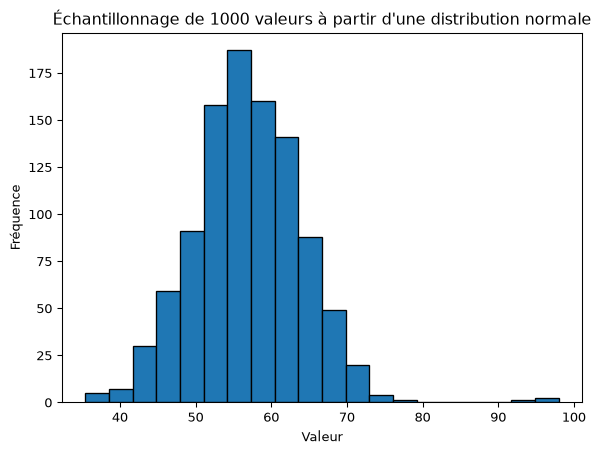

## Normalisation

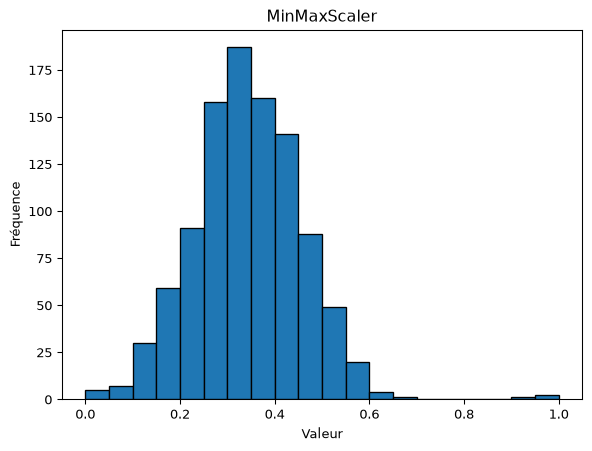

In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

minmax_norm_values = scaler.fit_transform(norm_values.reshape(-1, 1))

# Tracer l'histogramme
plt.hist(minmax_norm_values, bins=20, edgecolor='black')

plt.title(f'MinMaxScaler')

plt.xlabel('Valeur')
plt.ylabel('Fréquence')

plt.show()

Normalisation (`MinMaxScaler`) des valeurs d’une distribution normale
contenant des valeurs aberrantes.

Observez que la majorité des valeurs se situe dans la plage de 0 à 0,6,
tandis que l’intervalle de 0,6 à 1,0 est remarquablement peu dense. De
plus, bien que les échantillons proviennent d’une distribution normale,
les données sont centrées autour de 0,3 plutôt que sur la moyenne
attendue de 0,5.

## Standardisation

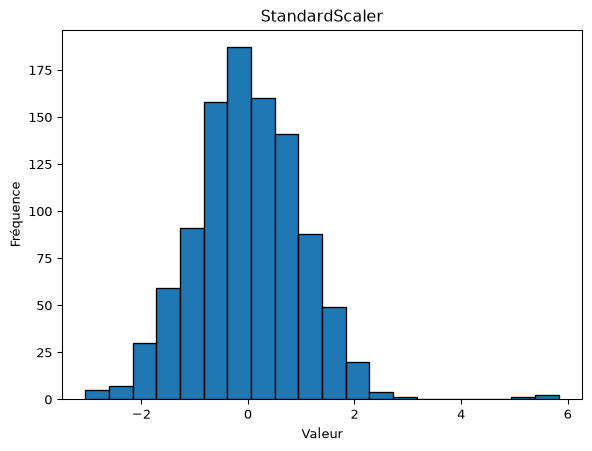

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

standard_norm_values = scaler.fit_transform(norm_values.reshape(-1, 1))

# Tracer l'histogramme
plt.hist(standard_norm_values, bins=20, edgecolor='black')

plt.title(f'StandardScaler')

plt.xlabel('Valeur')
plt.ylabel('Fréquence')

plt.show()

Standardisation (`StandardScaler`) des valeurs d’une distribution
normale contenant des valeurs aberrantes.

Lors de l’examen du graphique résultant de la standardisation, il
ressemble à celui de la normalisation. Néanmoins, une inspection plus
approfondie des valeurs révèle que la distribution des données est
centrée autour de zéro, avec environ 95 % des observations se situant
dans la plage de -2 à 2. Il est important de noter que, contrairement à
la normalisation, le `StandardScaler` n’impose pas de limites aux
valeurs de sortie.

## Logarithme

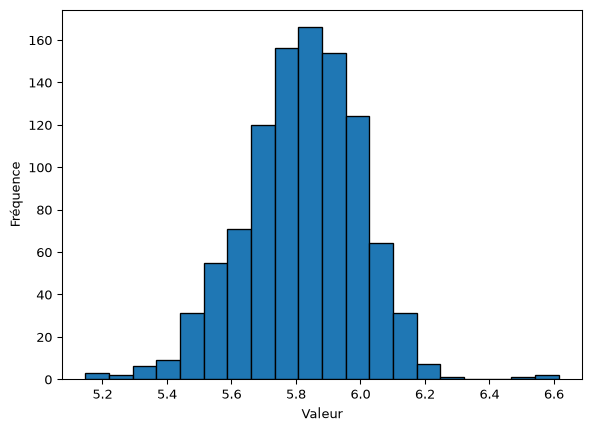

Logarithme des valeurs d’une distribution normale contenant des valeurs
aberrantes.

## Logarithme & Standardisation

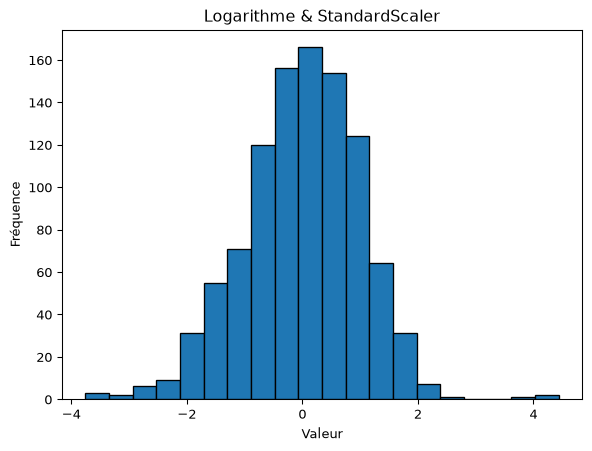

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

standard_log_norm_values = scaler.fit_transform(log_norm_values.reshape(-1, 1))

# Tracer l'histogramme
plt.hist(standard_log_norm_values, bins=20, edgecolor='black')

plt.title(f'Logarithme & StandardScaler')

plt.xlabel('Valeur')
plt.ylabel('Fréquence')

plt.show()

Standardisation (`StandardScaler`) des valeurs d’une distribution
normale contenant des valeurs aberrantes.

## Distribution exponentielle

In [31]:
# Taille de l'échantillon

sample_size = 1000

# Générer des valeurs

exp_values = np.random.exponential(scale=4, size=sample_size) + 20

Dans l’expression `NumPy`
`np.random.exponential(scale=4, size=sample_size) + 20`, le paramètre
`scale` se réfère au taux inverse (ou à la moyenne) de la distribution
exponentielle à partir de laquelle les échantillons aléatoires sont
générés. Plus précisément, la distribution exponentielle est définie par
son paramètre de taux, et `scale` est le réciproque de ce taux,
c’est-à-dire $\text{scale} = \frac{1}{\lambda}$.

Ainsi, `scale=4` signifie que la moyenne de la distribution
exponentielle est 4. L’argument `size=sample_size` spécifie le nombre
d’échantillons aléatoires à générer. Après la génération de ces
échantillons, 20 est ajouté à chacun, déplaçant ainsi toute la
distribution de 20 unités.

## Distribution exponentielle

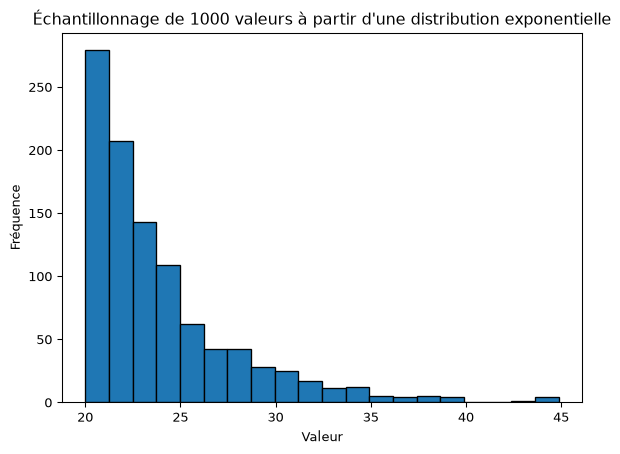

## Logarithme

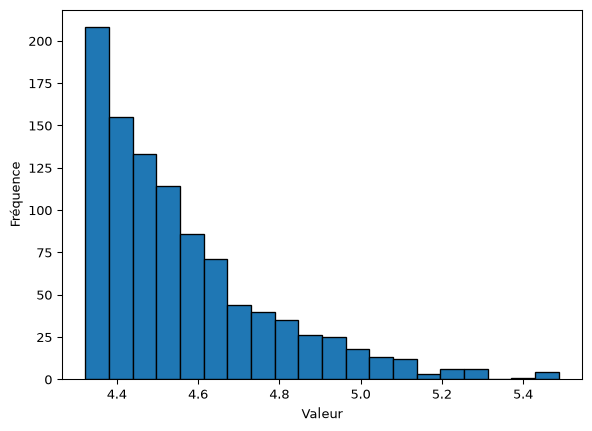

Logarithme des valeurs d’une distribution exponentielle.

## Normalisation

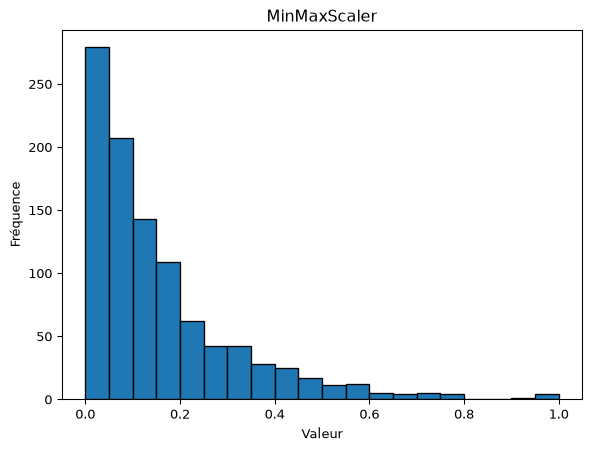

In [34]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

minmax_exp_values = scaler.fit_transform(exp_values.reshape(-1, 1))

# Tracer l'histogramme
plt.hist(minmax_exp_values, bins=20, edgecolor='black')

plt.title(f'MinMaxScaler')

plt.xlabel('Valeur')
plt.ylabel('Fréquence')

plt.show()

Normalisation (`MinMaxScaler`) des valeurs d’une distribution
exponentielle.

## Standardisation

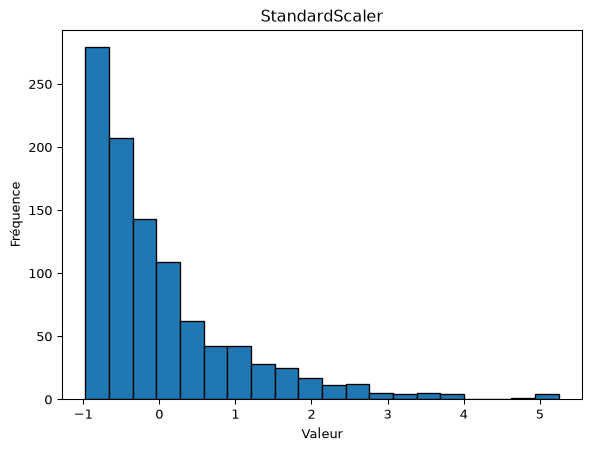

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

standard_exp_values = scaler.fit_transform(exp_values.reshape(-1, 1))

# Tracer l'histogramme
plt.hist(standard_exp_values, bins=20, edgecolor='black')

plt.title(f'StandardScaler')

plt.xlabel('Valeur')
plt.ylabel('Fréquence')

plt.show()

Standardisation (`StandardScaler`) des valeurs d’une distribution
exponentielle.

## Logarithme & Standardisation

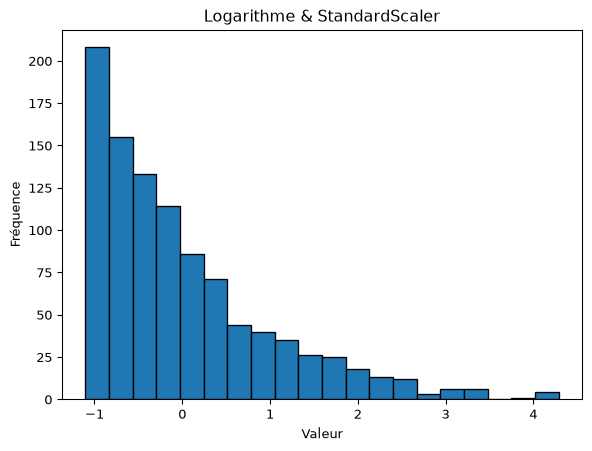

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

standard_log_exp_values = scaler.fit_transform(log_exp_values.reshape(-1, 1))

# Tracer l'histogramme
plt.hist(standard_log_exp_values, bins=20, edgecolor='black')

plt.title(f'Logarithme & StandardScaler')

plt.xlabel('Valeur')
plt.ylabel('Fréquence')

plt.show()

Logarithme et standardisation (`StandardScaler`) des valeurs d’une
distribution exponentielle.

## Évitez la fuite de données !

Le **flux de travail correct** :

- Divisez vos données en un **ensemble d’entraînement** et un **ensemble
  de test**.
- Ajustez votre standardiseur (par exemple, `StandardScaler`) sur les
  **données d’entraînement** (`scaler.fit(X_train)`).
  - Cette étape apprend la moyenne et l’écart type des données
    d’entraînement.
- Transformez à la fois les données d’entraînement
  (`scaler.transform(X_train)`) et les données de test
  (`scaler.transform(X_test)`) en utilisant le standardiseur qui a été
  ajusté sur les données d’entraînement.

Vous devez apprendre les paramètres de mise à l’échelle (comme la
moyenne, l’écart type, le minimum ou le maximum) uniquement à partir des
données d’entraînement. Ne jamais utiliser l’ensemble complet de données
avant de le diviser.

Pourquoi ? L’ensemble de test est censé simuler de nouvelles données,
jamais vues. Si vous utilisez des informations de l’ensemble de test
pour mettre à l’échelle vos données d’entraînement, votre modèle
“triche” en ayant un aperçu des données de test. Cela s’appelle la fuite
de données et mènera à une évaluation trop optimiste des performances de
votre modèle.

## Lectures complémentaires

Amorim et al. (2023) applique 6 méthodes de mise à l’échelle sur 82 jeux
de données et évalue l’impact pour 20 algorithms d’apprentissage.

- “Results indicated that the choice of scaling technique signif-icantly
  affects classification performance and that choosing thewrong scaling
  technique can even be worse than not scalingthe data at all.”

Arora et al. (2021) s’intéresse spécifiquement à l’algorithme KNN.

Pour les algorithmes basés sur des distances, tels que KNN, il est
essentiel d’appliquer une méthode de mise à l’échelle uniforme à tous
les attributs. En revanche, d’autres types d’algorithmes peuvent
bénéficier de l’utilisation de méthodes de mise à l’échelle spécifiques
à chaque attribut.

# Valeurs manquantes

## Définition

Les **valeurs manquantes** font référence à l’absence de données ou de
valeurs dans un ensemble de données là où une valeur est attendue.

**Exemple**: L’**âge** est souvent une bonne illustration, car certains
patients peuvent ne pas divulguer leur âge pour des raisons de
confidentialité.

## Gestion des valeurs manquantes

- **Supprimer les exemples**:
  - Faisable si l’ensemble de données est **grand** et que l’**issue
    n’est pas affectée**.
- **Supprimer les attributs** :
  - Convient si cela **n’affecte pas** le résultat du projet.
- **Utiliser des algorithmes qui gèrent les données manquantes** :
  - Exemple : `XGBoost`
  - **Remarque** : Certains algorithmes comme
    `sklearn.linear_model.LinearRegression` **ne peuvent pas traiter**
    les valeurs manquantes.
- **Imputation des données** :
  - Remplacer les valeurs manquantes par des valeurs calculées.

## Définition

L’**imputation des données** est le processus consistant à remplacer les
valeurs manquantes dans un ensemble de données par des valeurs
substituées, généralement en utilisant des méthodes statistiques ou
d’apprentissage automatique.

## Stratégie d’imputation des données

Remplacer les valeurs manquantes par la **moyenne** ou la **médiane** de
l’**attribut**.

In [37]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X = imputer.fit_transform(X)

. . .

- **Inconvénients** : Ignore les corrélations entre les attributs et les
  relations complexes.

- **Imputation par la mode** : Remplacer les valeurs manquantes par la
  valeur la plus fréquente ; ignore également les corrélations entre les
  attributs.

L’imputation des données repose souvent sur plusieurs hypothèses qui
peuvent ne pas toujours être valides.

**Hypothèse de randomisation** : De nombreuses méthodes (comme
l’imputation par moyenne/médiane) supposent que l’absence de données est
indépendante de toutes autres données disponibles.

**Biais du modèle** : Des hypothèses de randomisation incorrectes
peuvent entraîner des estimations biaisées et des conclusions erronées.

**Perte d’information** : L’imputation peut obscurcir des schémas dans
les données, entraînant la perte d’informations précieuses pour des
modèles avancés.

Soyez prudent !

## Stratégie d’imputation des données

**Méthode de valeur spéciale** : Remplacer les valeurs manquantes par
une valeur en dehors de la plage normale (par exemple, utiliser -1 ou 2
pour des données normalisées entre \[0,1\]).

- **Objectif** : Permettre à l’algorithme d’apprentissage de reconnaître
  et de gérer correctement les valeurs manquantes.

La classe `SimpleImputer` inclut un paramètre nommé `add_indicator`.
Lorsque ce paramètre est défini sur `True`, il génère un attribut
supplémentaire pour chaque attribut ayant des valeurs manquantes. Cet
attribut indique si la valeur pour un exemple donné a été imputée. Ce
mécanisme permet aux classificateurs de développer des stratégies
spécifiquement adaptées pour gérer les données manquantes. Par exemple,
si l’utilisation de la médiane est inefficace pour un certain attribut,
le classificateur peut apprendre à ignorer cet attribut. De plus, si les
valeurs manquantes sont plus fortement corrélées avec une classe qu’une
autre, le classificateur peut intégrer cette information dans son
processus d’apprentissage.

## Stratégie d’imputation des données

- **Imputation par valeur intermédiaire** : Remplacer les valeurs
  manquantes par une valeur au milieu de la plage normale (par exemple,
  utiliser 0 pour des données distribuées entre \[-1,1\]).

  - **Données catégorielles** : Utiliser de petites valeurs numériques
    non nulles.
    - Exemple : Utiliser \[0.25, 0.25, 0.25, 0.25\] au lieu de \[1, 0,
      0, 0\] pour ‘Mauvais’, \[0, 1, 0, 0\] pour ‘Moyen’, \[0, 0, 1, 0\]
      pour ‘Bon’, et \[0, 0, 0, 1\] pour ‘Excellent’.
  - **Objectif** : Minimiser l’impact des valeurs imputées sur les
    résultats.

**Choix de la méthode** : L’efficacité des méthodes d’imputation peut
varier, et il est essentiel de comparer plusieurs techniques pour
déterminer la meilleure approche pour votre ensemble de données
spécifique.

## Approche alternative

- **Définition du problème** : Prédire des étiquettes inconnues
  (manquantes) pour des exemples donnés.
- Avez-vous déjà rencontré ce type de problème auparavant ?
- **Pertinence** : Cela peut être formulé comme un problème
  d’apprentissage supervisé.
  - Soit $\hat{x_i}$ un nouvel exemple :
    $[x_i^{(1)}, x_i^{(2)}, \ldots, x_i^{(j-1)}, x_i^{(j+1)}, \ldots, x_i^{(D)}]$.
  - Soit $\hat{y}_i = x_i^{j}$.
  - **Ensemble d’entraînement** : Utiliser des exemples où $x_i^{j}$
    n’est pas manquant.
  - **Méthode** : Entraîner un classificateur sur cet ensemble pour
    prédire (imputer) les valeurs manquantes.

## Utiliser l’apprentissage automatique pour l’imputation

1.  **Méthode basée sur les instances** :

    - Utiliser $k$ plus proches voisins (k-NN) pour trouver les $k$
      exemples les plus proches et imputer à l’aide des valeurs non
      manquantes du voisinage.

2.  **Méthodes basées sur des modèles** :

    - Utiliser des techniques avancées telles que les forêts aléatoires,
      la décomposition tensorielle ou les réseaux neuronaux profonds.

[Consultez ce
guide](https://scikit-learn.org/stable/modules/impute.html#nearest-neighbors-imputation)
ou encore
[KNNImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html).

## Pourquoi utiliser ces méthodes ?

- **Avantages** :
  - Traitent efficacement les relations complexes et les corrélations
    entre les attributs.
- **Inconvénients** :
  - Coût-intensif en termes de temps de travail, de CPU et de ressources
    mémoire.

# Déséquilibre des classes

## Définition

Le **problème de déséquilibre des classes** (*class imbalance*) survient
lorsqu’un grand nombre d’exemples appartient à une classe majoritaire,
tandis qu’un nombre relativement faible d’exemples appartient à une ou
plusieurs classes minoritaires.

. . .

Les modèles ont tendance à favoriser la **classe majoritaire**, ce qui
conduit à de **mauvaises performances sur la classe minoritaire**.

Les mesures d’évaluation standard comme l’exactitude (*accuracy*)
peuvent être trompeuses en présence d’un déséquilibre des classes.

## Solutions

- **Rééchantillonnage** :
  - Techniques comme le **suréchantillonnage** de la classe minoritaire
    ou le **sous-échantillonnage** de la classe majoritaire.
- **Ajustements algorithmiques** :
  - Utiliser l’apprentissage sensible aux coûts ou ajuster les seuils de
    décision.

    - Voir `class_weight` de
      [SGDClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html).
- **Données synthétiques** :
  - Générer des exemples synthétiques pour la classe minoritaire en
    utilisant des méthodes comme SMOTE (Synthetic Minority Over-sampling
    Technique).

Appliquer les solutions uniquement à l’**ensemble d’entraînement** pour
éviter les **fuites de données**!

Le rééchantillonnage et SMOTE sont implémenté par
[`imbalanced-learn`](https://imbalanced-learn.org/stable/index.html).

L’article original de Chawla et al. (2002) présente SMOTE, tandis que
Pradipta et al. (2021) fournit un examen récent des méthodes.

### Suréchantillonnage

- **Inconvénient** : Le suréchantillonnage peut entraîner un
  surapprentissage, surtout si les exemples synthétiques sont très
  similaires aux exemples existants.
  - **Impact** : Le modèle peut bien fonctionner sur l’ensemble
    d’entraînement mais mal généraliser sur de nouvelles données.

### Sous-échantillonnage

- **Inconvénient** : Perte d’information due à la réduction du nombre
  d’exemples dans la classe majoritaire.
  - **Impact** : Risque de sous-apprentissage et modèle moins précis.
- **Réduction des performances du modèle** : Un ensemble d’entraînement
  plus petit peut ne pas capturer la complexité du problème.
  - **Impact** : Peut entraîner un modèle moins précis et moins robuste.

### Qu’est-ce que `class_weight` ?

- `class_weight` est une option que vous passez à `SGDClassifier(...)`
  pour indiquer à l’algorithme de **mettre l’accent** sur certaines
  classes plus (ou moins) pendant l’entraînement.
- Il ajuste la perte par exemple en fonction de l’étiquette de classe,
  de sorte que les classes « rares » ou « importantes » contribuent
  davantage à l’objectif.

### Comment cela affecte l’entraînement (intuitivement)

1.  Supposons que vous ayez des classes (A) et (B). Vous définissez
    `class_weight = {A: w_A, B: w_B}` (ou utilisez `"balanced"` pour
    calculer les poids automatiquement).
2.  Pendant la descente de gradient stochastique (SGD), pour une
    instance d’entraînement ($(x, y)$), le terme de perte
    ($\ell(y, f(x))$) est multiplié par le poids de la classe ($w_y$).
3.  La mise à jour du gradient / paramètre pour ce point d’entraînement
    est mise à l’échelle par ($w_y$).
    - Ainsi, les échantillons de la classe (A) avec un (w_A) plus élevé
      “tirent plus fort” sur le modèle.
4.  Effet : le modèle est biaisé pour réduire davantage les erreurs sur
    les classes avec des poids plus élevés.

### Équilibrage automatique : `class_weight = "balanced"`

- Si vous définissez `class_weight="balanced"`, `SGDClassifier`
  calculera en interne les poids des classes comme suit : $$
  w_j = \frac{N}{K \cdot n_j}
  $$ où
  - $N$ = nombre total d’échantillons
  - $K$ = nombre de classes
  - $n_j$ = nombre d’échantillons dans la classe ($j$)
- Ainsi, les classes plus rares obtiennent des poids plus élevés.

### Faits clés & mises en garde

- `class_weight` n’est pris en compte que s’il est fourni dans le
  **constructeur**, pas (effectivement) dans l’appel `fit(...)`.

- Le poids de la classe est **multiplié** par tout `sample_weight` (si
  vous le fournissez également) pour calculer le poids effectif de
  chaque exemple.

- Si vous définissez des poids de classe de manière trop agressive,
  l’entraînement peut devenir instable ou le modèle peut surajuster les
  classes minoritaires.

- [compute_class_weight — documentation scikit-learn
  1.6.1](https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html)

- [SGDClassifier – class_weights & sample_weights #3928 -
  GitHub](https://github.com/scikit-learn/scikit-learn/issues/3928)

- [Comment fonctionne sample_weight dans SGDClassifier ? - Stack
  Overflow](https://stackoverflow.com/questions/55908022/how-does-sample-weight-work-in-sgdclassifier)

# Nouveaux attributs

## Définition

**L’ingénierie des attributs** est le processus de **création**,
**transformation** et **sélection** de variables (attributs) à partir de
données brutes pour améliorer la performance des modèles d’apprentissage
automatique.

Ici, notre objectif est de **créer** de nouveaux attributs à partir de
données brutes.

## Exploration

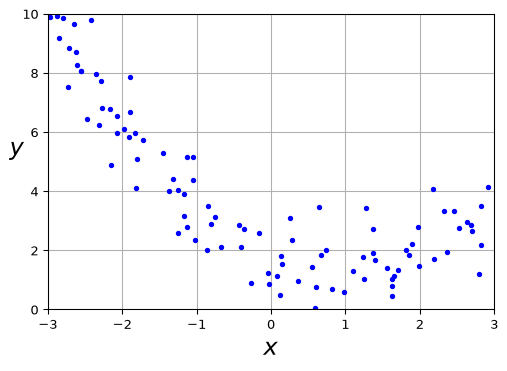

In [38]:
import numpy as np

np.random.seed(42)

X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X ** 2 - X + 2 + np.random.randn(100, 1)

import matplotlib as mpl
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(X, y, "b.")
plt.xlabel("$x$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
plt.grid(True)
plt.show()

**Attribution** : Géron (2022), Chapitre 4

Dans les expériences d’apprentissage automatique, spécifier le germe du
générateur de nombres aléatoires est crucial pour garantir la
reproductibilité. En fixant un germe, les programmeurs peuvent garantir
que la même séquence de nombres aléatoires sera générée à chaque
exécution de l’expérience. Cette cohérence est vitale pour plusieurs
raisons :

1.  **Reproductibilité** : Elle permet à d’autres programmeurs de
    reproduire l’expérience dans les mêmes conditions exactes,
    facilitant la vérification et la validation des résultats.
2.  **Analyse comparative** : Elle permet une comparaison cohérente
    entre différents modèles ou algorithmes dans les mêmes conditions
    initiales, garantissant que les différences observées sont dues aux
    modèles eux-mêmes plutôt qu’à des variations dans l’initialisation
    aléatoire.
3.  **Débogage** : Elle aide au débogage en fournissant un environnement
    stable où les problèmes peuvent être reproduits et étudiés de
    manière cohérente.

## Régression linéaire

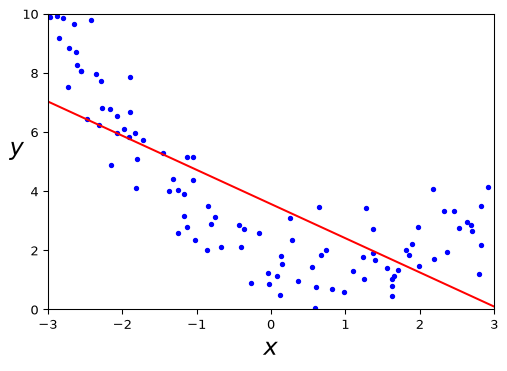

In [39]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

X_new = np.array([[-3], [3]])
y_pred = lin_reg.predict(X_new)

plt.figure(figsize=(6,4))

plt.plot(X, y, "b.")
plt.plot(X_new, y_pred, "r-")
plt.xlabel("$x$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
plt.show()

Un **modèle linéaire** représente mal ces données.

Ajuster la pente conduit invariablement à un scénario où les résidus
(erreurs) sont minimisés pour certains points de données tout en restant
significatifs pour d’autres.

## Ingénierie de l’apprentissage automatique

![](https://m.media-amazon.com/images/I/51XUfJm64KL._AC_UF350,350_QL50_.jpg)

- [**Machine Learning
  Engineering**](http://www.mlebook.com/wiki/doku.php) par [Andriy
  Burkov](https://www.linkedin.com/in/andriyburkov) (Burkov 2020).
- Couvre la collecte de données, le stockage, le prétraitement,
  l’ingénierie des attributs, le test et le débogage des modèles, le
  déploiement, la retraite et la maintenance.
- De l’auteur de [**Hundred Page Machine Learning
  Book**](https://themlbook.com) (Burkov 2019).
- Disponible sous un modèle “lire d’abord, acheter plus tard”.

## `PolynomialFeatures`

In [40]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

. . .

In [41]:
X[0]

array([-0.75275929])

. . .

In [42]:
X_poly[0]

array([-0.75275929,  0.56664654])

. . .

> 
> **[sklearn.preprocessing.PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)**
>
> Générez une nouvelle matrice d’attributs constituée de toutes les
> combinaisons polynomiales des attributs avec un degré inférieur ou
> égal au degré spécifié. Par exemple, si un échantillon d’entrée est
> bidimensionnel et de la forme $[a, b]$, les attributs polynomials de
> degré 2 sont $[1, a, b, a^2, ab, b^2]$.

## `PolynomialFeatures`

Étant donné deux attributs $a$ et $b$, `PolynomialFeatures` avec
`degree=3` ajouterait $a^2$, $a^3$, $b^2$, $b^3$, ainsi que $ab$,
$a^2b$, $ab^2$ !

. . .

> **Warning**
>
> `PolynomialFeatures(degree=d)` ajoute $\frac{(D+d)!}{d!D!}$ attributs,
> où $D$ est le nombre initial d’attributs.

De plus, vous avez la possibilité de créer vos propres nouveaux
attributs.

## Régression polynomiale

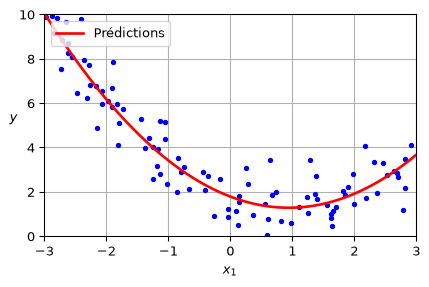

In [43]:
lin_reg = LinearRegression()
lin_reg = lin_reg.fit(X_poly, y)

X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(5, 3))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Prédictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

`LinearRegression` sur `PolynomialFeatures`

In [44]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

## Régression polynomiale

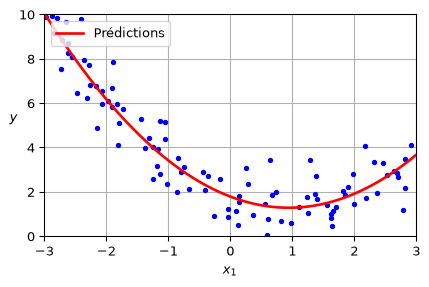

Les données ont été générées selon l’équation suivante, avec l’inclusion
de bruit gaussien.

$$
  y = 0.5 x^2 - 1.0 x + 2.0
$$

Présenté ci-dessous est le modèle appris.

$$
  \hat{y} = 0.56 x^2 + (-1.06) x + 1.78
$$

In [46]:
lin_reg.coef_, lin_reg.intercept_

(array([[-1.06633107,  0.56456263]]), array([1.78134581]))

### 1. **La linéarité concerne les coefficients, pas les entrées brutes**

- La régression logistique est linéaire dans ses **paramètres** (poids).
- La frontière de décision provient de :

$$
\hat{y_i} = \sigma(\theta_0 + \theta_1 z_i^{(1)} + \theta_2 z_i^{(2)} + \dots + \theta_{D'} z_i^{(D')})
$$

où chaque $z_i^{(j)}$ est un attribut.

- Si vous définissez $z_i^{(j)}$ comme une fonction polynomiale des
  variables originales (par exemple $z_i^{(3)} = (x_i^{(1)})^2$), le
  modèle reste *linéaire dans les $z_i^{(j)}$*.

### 2. **PolynomialFeatures ne fait que changer l’espace des attributs**

- `PolynomialFeatures` transforme l’entrée $(x_i^{(1)}, x_i^{(2)})$ en
  un nouveau vecteur :
  $(x_i^{(1)}, x_i^{(2)}, (x_i^{(1)})^2, x_i^{(1)}x_i^{(2)}, (x_i^{(2)})^2, \ldots)$.
- La régression logistique trouve alors une frontière de décision
  linéaire dans cet **espace d’attributs étendu**.
- Lorsque vous le mappez de nouveau à l’espace original
  $(x_i^{(1)}, x_i^{(2)})$, cette surface de décision “linéaire” peut
  apparaître courbée ou sinueuse, mais mathématiquement c’est toujours
  un hyperplan dans l’espace transformé.

**Message clé :**

“La régression logistique trouve toujours une frontière linéaire dans
les attributs que vous lui fournissez. Si vous lui fournissez des
polynômes, la frontière linéaire dans cet espace semble non linéaire
dans l’espace original.”

# Les données

## La taille compte

“Cependant, ces résultats suggèrent que nous devrions peut-être
reconsidérer l’équilibre entre passer du temps et de l’argent à
développer des algorithmes, contre **investir dans le développement de
corpus**.”

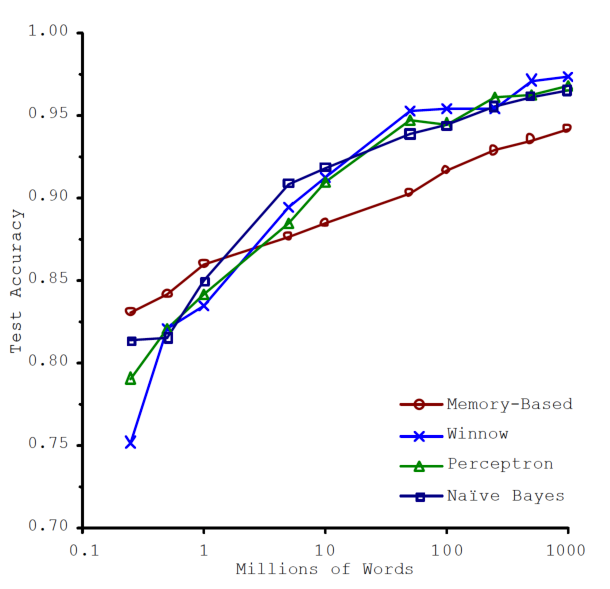

**Attribution**: Banko et Brill (2001)

## Efficacité déraisonnable des données

<https://youtu.be/yvDCzhbjYWs>

Halevy et al. (2009) et Kaplan et al. (2020).

La présentation de Peter Norvig, intitulée “L’efficacité déraisonnable
des données”, dure un peu plus d’une heure. Il est à noter que l’article
sur lequel cette présentation est basée a été publié en 2009, avant le
succès d’AlexNet.

Les améliorations substantielles observées avec AlexNet en 2012 ont mis
en évidence les avantages de l’entraînement de réseaux neuronaux
profonds sur de grands ensembles d’images.

De même, les modèles modernes tels que GPT, Gemini, Claude et LLaMA ont
réalisé des progrès significatifs dans les capacités linguistiques en
s’entraînant sur des quantités massives de textes, englobant presque
toute la littérature écrite depuis le début de la civilisation humaine.

Les **lois d’échelle neuronale** décrivent comment les performances des
réseaux neuronaux varient en fonction de facteurs clés comme la taille
des ensembles de données, le nombre de paramètres et les coûts
computationnels Kaplan et al. (2020).

## Définition

**L’augmentation des données** (*data augmentation*) est une technique
utilisée pour accroître la diversité d’un ensemble de données en
appliquant diverses transformations aux données existantes.

**But**: Améliorer la robustesse et la capacité de généralisation des
modèles d’apprentissage automatique.

## Augmentation des données

- **Pour les images**: Rotations, translations, redimensionnement,
  renversement, ajout de bruit, etc.
  - [How to find ancient geoglyphs using machine
    learning?](https://youtube.com/shorts/DA_-6296G5o), Sakai et al.
    (2024)
- **Pour les textes**: Remplacement de synonymes, insertion aléatoire,
  suppression, et permutation des mots.

Les **réseaux antagonistes génératifs (GANs)** (une forme
d’apprentissage profond) peuvent être utilisés pour générer de nouvelles
données synthétiques qui imitent la distribution de l’ensemble de
données original. Voir aussi : Shumailov et al. (2024).

# Prologue

## Lectures complémentaires

![](https://m.media-amazon.com/images/I/51XUfJm64KL._AC_UF350,350_QL50_.jpg)

- [**Machine Learning
  Engineering**](http://www.mlebook.com/wiki/doku.php) par [Andriy
  Burkov](https://www.linkedin.com/in/andriyburkov) (Burkov 2020).

- Traite de la collecte de données, du stockage, du prétraitement, de
  l’ingénierie des caractéristiques, du test et du débogage des modèles,
  du déploiement, de la mise hors service, et de la maintenance.

- Par l’auteur de [**The Hundred-Page Machine Learning
  Book**](https://themlbook.com) (Burkov 2019).

- Disponible sous un modèle “lire d’abord, acheter plus tard”.

## Résumé

- **Encodage des attributs** : Évaluation des techniques éviter des
  biais et possiblement faciliter l’apprentissage.
- **Prétraitement** :
  - Mise à l’échelle des données
  - Gestion des valeurs manquantes
  - Gestion du déséquilibre des classes
- **Taille de l’ensemble d’entraînement** : Impact sur l’efficacité du
  modèle et la généralisation.

## Prochain cours

- Introduction aux réseaux neuronaux artificiels.

## Références

Amorim, Lucas B. V. de, George D. C. Cavalcanti, et Rafael M. O. Cruz.
2023. « The choice of scaling technique matters for classification
performance ». *Applied Soft Computing* 133: 109924.
<https://doi.org/10.1016/j.asoc.2022.109924>.

Arora, Ishan, Namit Khanduja, et Mayank Bansal. 2021. « Effect of
Distance Metric and Feature Scaling on KNN Algorithm while Classifying
X-rays ». *RIF’21: The 10th Seminary of Computer Science Research at
Feminine* (Constantine 2-Abdelhamid Mehri University, Algeria).
<https://api.semanticscholar.org/CorpusID:251472012>.

Banko, Michele, et Eric Brill. 2001. « Scaling to very very large
corpora for natural language disambiguation ». *Proceedings of the 39th
Annual Meeting on Association for Computational Linguistics* (USA), ACL
’01, 26‑33. <https://doi.org/10.3115/1073012.1073017>.

Burkov, A. 2020. *Machine Learning Engineering*. True Positive
Incorporated. <https://books.google.ca/books?id=HeXizQEACAAJ>.

Burkov, Andriy. 2019. *The Hundred-Page Machine Learning Book*. Andriy
Burkov.

Chawla, N V, K W Bowyer, L O Hall, et W P Kegelmeyer. 2002. « SMOTE:
Synthetic minority over-sampling technique ». *Journal of Artificial
Intelligence Research* 16: 321‑57.

Géron, Aurélien. 2022. *Hands-on Machine Learning with Scikit-Learn,
Keras, and TensorFlow*. 3ᵉ éd. O’Reilly Media, Inc.

Halevy, Alon, Peter Norvig, et Fernando Pereira. 2009. « The
Unreasonable Effectiveness of Data ». *IEEE Intelligent Systems* 24 (2):
8‑12.

Kaplan, Jared, Sam McCandlish, Tom Henighan, et al. 2020. *Scaling Laws
for Neural Language Models*. <https://arxiv.org/abs/2001.08361>.

Pradipta, Gede Angga, Retantyo Wardoyo, Aina Musdholifah, I Nyoman
Hariyasa Sanjaya, et Muhammad Ismail. 2021. « SMOTE for Handling
Imbalanced Data Problem : A Review ». *2021 Sixth International
Conference on Informatics and Computing (ICIC)* 00: 1‑8.
<https://doi.org/10.1109/icic54025.2021.9632912>.

Russell, Stuart, et Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4ᵉ éd. Pearson. <http://aima.cs.berkeley.edu/>.

Sakai, Masato, Akihisa Sakurai, Siyuan Lu, et al. 2024. « AI-accelerated
Nazca survey nearly doubles the number of known figurative geoglyphs and
sheds light on their purpose ». *Proceedings of the National Academy of
Sciences* 121 (40): e2407652121.
<https://doi.org/10.1073/pnas.2407652121>.

Shumailov, Ilia, Zakhar Shumaylov, Yiren Zhao, Nicolas Papernot, Ross
Anderson, et Yarin Gal. 2024. « AI models collapse when trained on
recursively generated data ». *Nature* 631 (8022): 755‑59.
<https://doi.org/10.1038/s41586-024-07566-y>.

# Annexe : Pipeline

## Pipeline

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('attribs_adder', CombinedAttributesAdder()),
        ('std_scaler', StandardScaler()),
        ])

training_num_tr = num_pipeline.fit_transform(training_num)

full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", OneHotEncoder(), ["sequence"]),
    ])

training_prepared = full_pipeline.fit_transform(training)

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

École de **science informatique** et de génie électrique (**SI**GE)

Université d’Ottawa

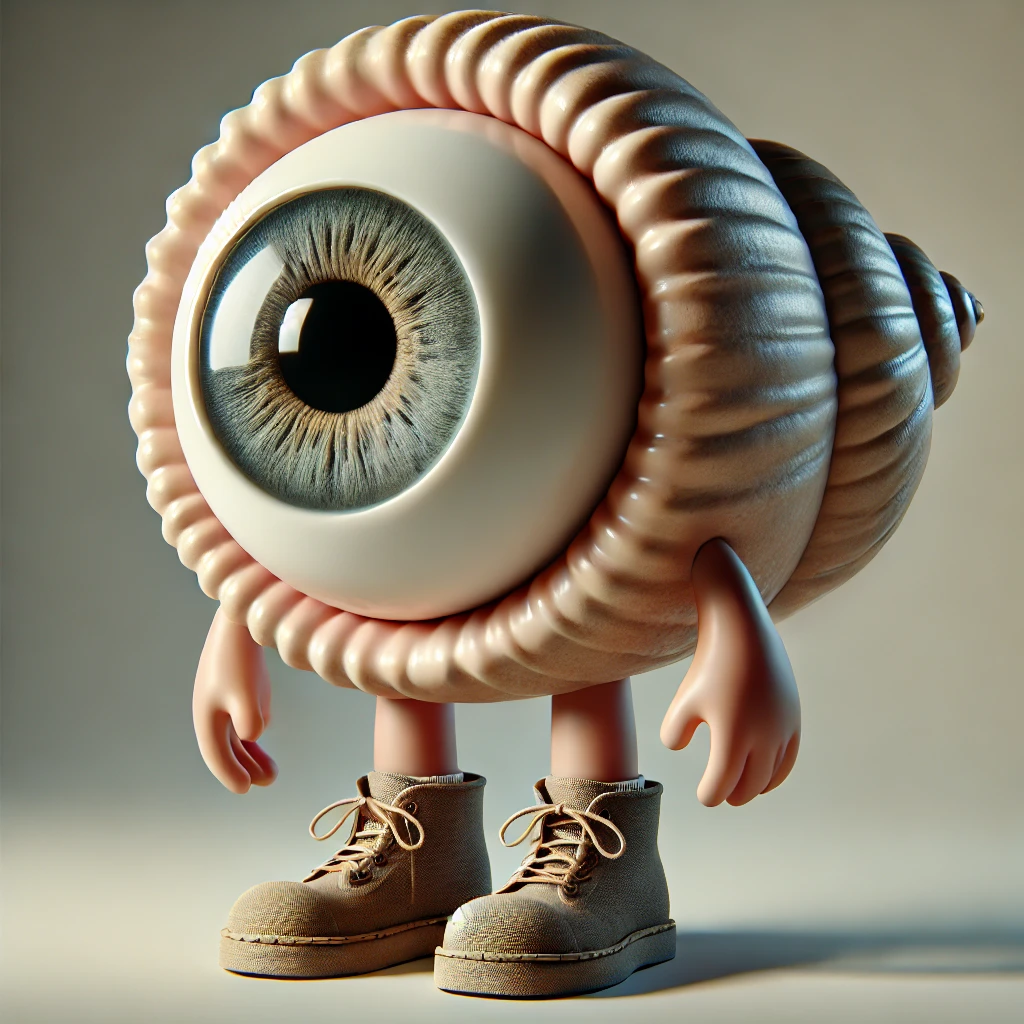

**Attribution**: Générée par DALL-E, via ChatGPT (GPT-4), OpenAI, 20
septembre, 2024.

Voir la page suivante pour les interactions.

## GPT-4o interactions 2024-09-30

**J’ai présenté à GPT-4o une image du personnage principal de [Marcel
the Shell With Shoes
On](https://a24films.com/films/marcel-the-shell-with-shoes-on) et j’ai
eu les interactions suivantes.**

**Marcel:** How would you describe the subject of the image, its
artistic quality, technique, and rendering style?

**GPT-4o**: The image depicts a whimsical character that resembles a
small shell with one large, expressive eye. It stands on two legs
wearing shoes, giving it a cute and almost anthropomorphic appearance.
The character has a surreal and quirky look, which lends it a sense of
personality and charm.

**Artistic Quality**:

The image is rendered with a high degree of polish and smoothness,
possibly created digitally. The textures, shading, and lighting are soft
and subtle, giving the character a smooth and rounded look. The
rendering captures a delicate balance between realism (in the textures
of the shell and shoes) and cartoon-like abstraction (in the exaggerated
eye and small stature).

**Technique**:

The artist appears to have employed a blend of digital painting and
3D-like modeling techniques, with careful attention to detail in the
reflections in the eye and the textures of the shell and shoes. The
color palette is muted, using soft tones that evoke a gentle, friendly
atmosphere.

**Rendering Style**:

The rendering style is a mix of minimalist and hyperrealist elements.
The minimalism is seen in the simplified forms of the
character—particularly the body and legs—while the hyperrealism comes
through in the detailing of the eye and the subtle textures. This gives
the character a tactile, almost tangible quality while maintaining its
fantastical, imaginative essence.

The overall effect of the design is both charming and surreal, combining
everyday objects (a shell, shoes) with anthropomorphic and fantastical
elements to create a unique, playful character.

**Marcel:** Create an image based on the following description: The
image depicts a whimsical character that resembles a small shell with
one large, expressive eye. It stands on two legs wearing shoes, giving
it a cute and almost anthropomorphic appearance. The character has a
surreal and quirky look, which lends it a sense of personality and
charm.

**Artistic Quality**:

The image is rendered with a high degree of polish and smoothness,
possibly created digitally. The textures, shading, and lighting are soft
and subtle, giving the character a smooth and rounded look. The
rendering captures a delicate balance between realism (in the textures
of the shell and shoes) and cartoon-like abstraction (in the exaggerated
eye and small stature).

**Technique**:

The artist appears to have employed a blend of digital painting and
3D-like modeling techniques, with careful attention to detail in the
reflections in the eye and the textures of the shell and shoes. The
color palette is muted, using soft tones that evoke a gentle, friendly
atmosphere.

**Rendering Style**:

The rendering style is a mix of minimalist and hyperrealist elements.
The minimalism is seen in the simplified forms of the
character—particularly the body and legs—while the hyperrealism comes
through in the detailing of the eye and the subtle textures. This gives
the character a tactile, almost tangible quality while maintaining its
fantastical, imaginative essence.

The overall effect of the design is both charming and surreal, combining
everyday objects (a shell, shoes) with anthropomorphic and fantastical
elements to create a unique, playful character.

**GTP-4o**: Here is the image based on the description you provided. Let
me know if you’d like to make any adjustments!